In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [17]:
import subprocess
subprocess.run(['pip', 'install', 'grad-cam', '-q'], check=True)
print("✅ Installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 45.0 MB/s eta 0:00:00
✅ Installed!


In [18]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

✅ Device: cpu


In [19]:
checkpoint = torch.load(
    '/kaggle/input/datasets/dhathrikarthik/deepfake-classifier-weights/deepfake_classifier.pth',
    map_location=device
)

# Strip the 'model.' prefix from all keys
fixed_state_dict = {k.replace('model.', '', 1): v for k, v in checkpoint.items()}

model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model.load_state_dict(fixed_state_dict)
model = model.to(device)
model.eval()
print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

DATA_ROOT  = '/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake'
OUTPUT_DIR = '/kaggle/working/outputs/gradcam'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LABELS = {0: 'Real', 1: 'Fake'}
print("✅ Imports & config done!")

✅ Imports & config done!


In [34]:
target_layer = [model.features[-3]]
print("✅ Target layer set!")

✅ Target layer set!


In [35]:
from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])
print("✅ Transforms ready!")

✅ Transforms ready!


In [36]:
def run_gradcam(img_path, true_label=None):
    pil_img = Image.open(img_path).convert('RGB').resize((224, 224))
    rgb_img = np.array(pil_img, dtype=np.float32) / 255.0
    input_t = preprocess(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_t)
        probs  = torch.softmax(logits, dim=1)
        pred   = probs.argmax(dim=1).item()
        conf   = probs[0, pred].item()

    with EigenCAM(model=model, target_layers=target_layer) as cam:
        targets   = [ClassifierOutputTarget(pred)]
        grayscale = cam(input_tensor=input_t, targets=targets)[0]

    heatmap = show_cam_on_image(rgb_img, grayscale, use_rgb=True)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(pil_img);               axes[0].set_title('Original');        axes[0].axis('off')
    axes[1].imshow(grayscale, cmap='jet'); axes[1].set_title('GradCAM Heatmap'); axes[1].axis('off')
    axes[2].imshow(heatmap);               axes[2].set_title('Overlay');          axes[2].axis('off')

    label_str = f"Pred: {LABELS[pred]} ({conf*100:.1f}%)"
    if true_label:
        correct = true_label.lower() == LABELS[pred].lower()
        label_str += f"  |  True: {true_label.capitalize()}"
        fig.suptitle(label_str, fontsize=13, color='green' if correct else 'red')
    else:
        fig.suptitle(label_str, fontsize=13)

    fname = os.path.join(OUTPUT_DIR, os.path.basename(img_path))
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    return LABELS[pred], conf

print("✅ GradCAM function defined!")

✅ GradCAM function defined!


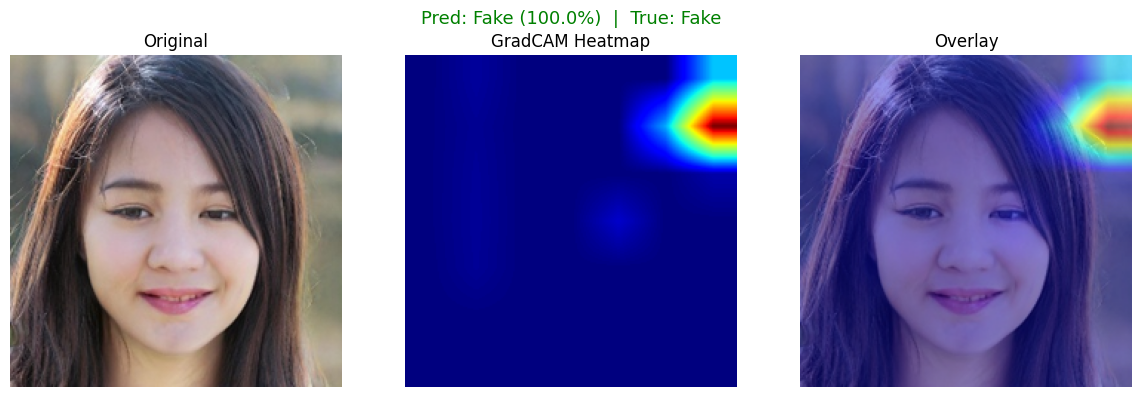

[FAKE] 00276TOPP4.jpg → Fake (100.0%)


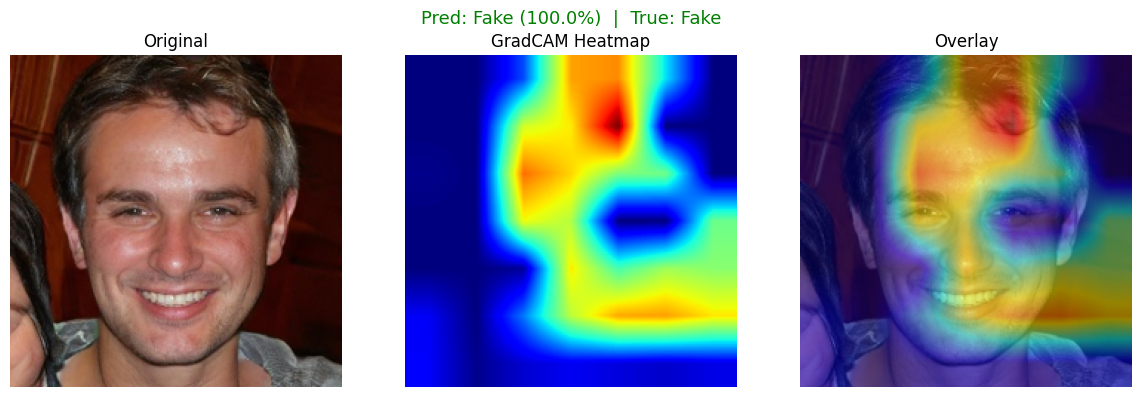

[FAKE] 008BYSE725.jpg → Fake (100.0%)


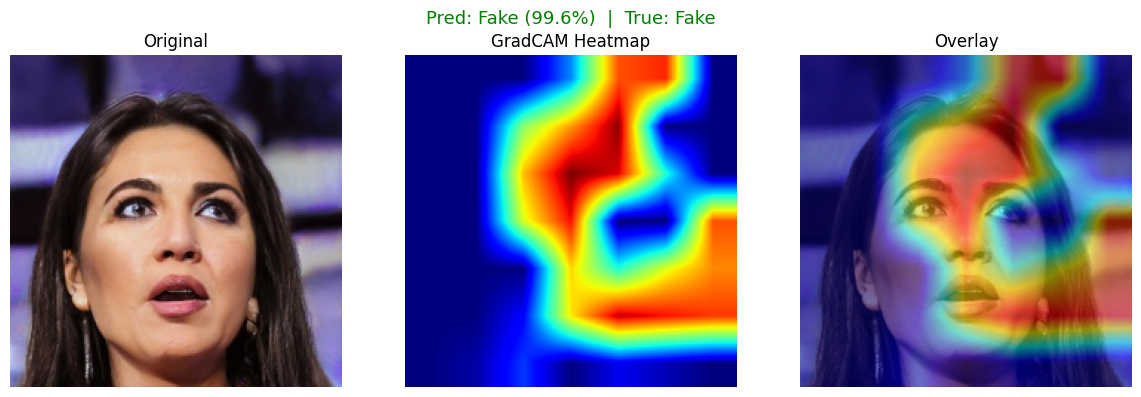

[FAKE] 009ZTJ3621.jpg → Fake (99.6%)


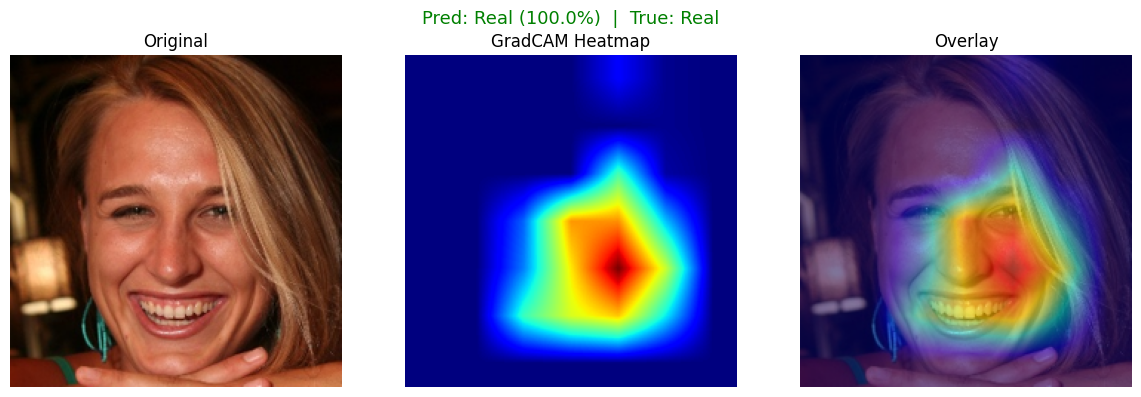

[REAL] 00001.jpg → Real (100.0%)


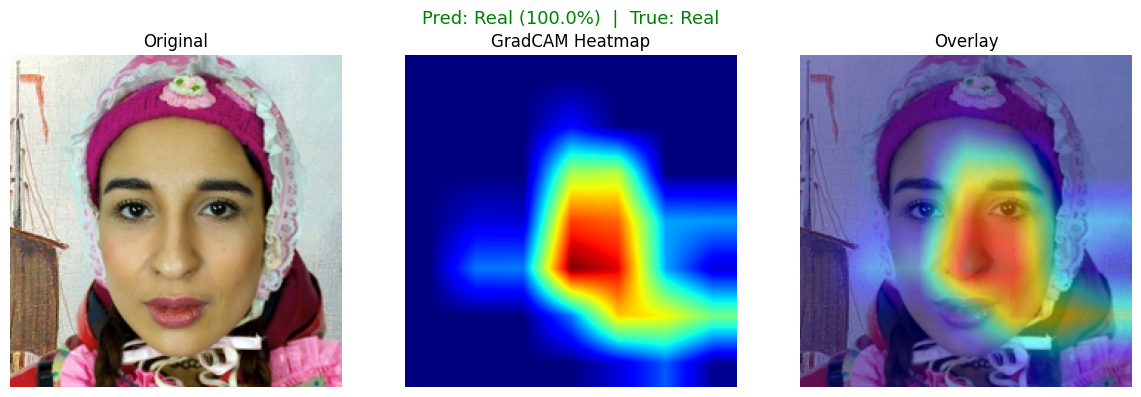

[REAL] 00004.jpg → Real (100.0%)


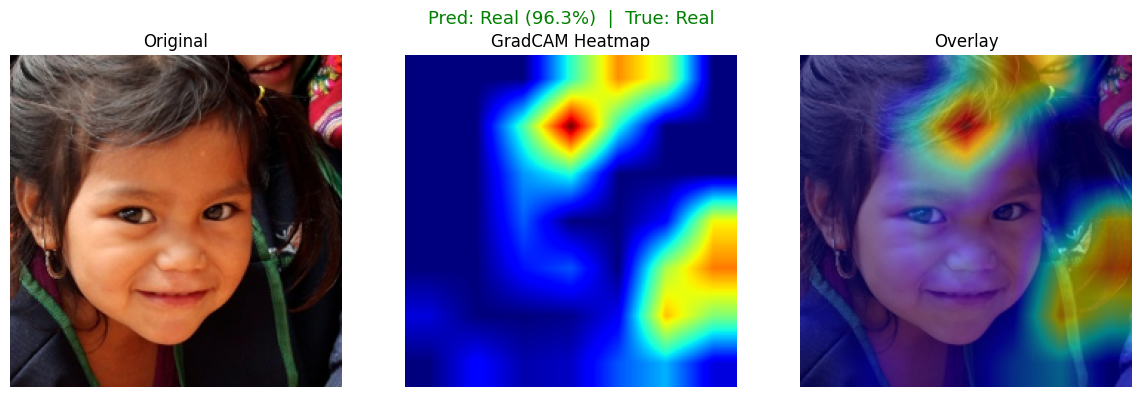

[REAL] 00007.jpg → Real (96.3%)


In [23]:
sample_images = [
    (f'{DATA_ROOT}/test/fake', 'fake'),
    (f'{DATA_ROOT}/test/real', 'real'),
]

for folder, true_label in sample_images:
    imgs = sorted(os.listdir(folder))[:3]
    for img_name in imgs:
        img_path = os.path.join(folder, img_name)
        pred_label, conf = run_gradcam(img_path, true_label=true_label)
        print(f"[{true_label.upper()}] {img_name} → {pred_label} ({conf*100:.1f}%)")

In [37]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

SEG_OUTPUT_DIR = '/kaggle/working/outputs/segmentation'
os.makedirs(SEG_OUTPUT_DIR, exist_ok=True)

print("✅ Segmentation imports done!")

✅ Segmentation imports done!


In [38]:
def run_segmentation(img_path, true_label=None, threshold=0.6):
    # ── Get heatmap from EigenCAM ─────────────────────────────────────────────
    pil_img = Image.open(img_path).convert('RGB').resize((224, 224))
    rgb_img = np.array(pil_img, dtype=np.float32) / 255.0
    input_t = preprocess(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_t)
        probs  = torch.softmax(logits, dim=1)
        pred   = probs.argmax(dim=1).item()
        conf   = probs[0, pred].item()

    with EigenCAM(model=model, target_layers=target_layer) as cam:
        targets   = [ClassifierOutputTarget(pred)]
        grayscale = cam(input_tensor=input_t, targets=targets)[0]  # (224,224) float 0-1

    # ── Binary mask — only for Fake predictions ───────────────────────────────
    if pred == 1:  # 1 = Fake
        binary_mask = (grayscale >= threshold).astype(np.uint8) * 255
    else:          # Real — no mask
        binary_mask = np.zeros((224, 224), dtype=np.uint8)

    # ── Clean up mask with morphological ops ──────────────────────────────────
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)  # fill holes
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN,  kernel)  # remove noise
    
    center_mask = np.zeros((224, 224), dtype=np.uint8)
    cv2.ellipse(center_mask,
                center=(112, 112),   # image center
                axes=(90, 110),      # width, height of ellipse
                angle=0,
                startAngle=0,
                endAngle=360,
                color=255,
                thickness=-1)        # filled ellipse
    binary_mask = cv2.bitwise_and(binary_mask, center_mask)

    # ── Fallback for Fake with empty mask ─────────────────────────────────────
    if pred == 1 and cv2.countNonZero(binary_mask) == 0:
        # Model predicted fake but couldn't localise — use default face ellipse
        binary_mask = np.zeros((224, 224), dtype=np.uint8)
        cv2.ellipse(binary_mask,
                    center=(112, 112),
                    axes=(70, 90),
                    angle=0, startAngle=0, endAngle=360,
                    color=255, thickness=-1)
        print(f"⚠️  {os.path.basename(img_path)}: Fake detected but weak localisation — using default face region")
    
    # ── Contour overlay on original ───────────────────────────────────────────
    contour_img = (rgb_img * 255).astype(np.uint8).copy()
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(contour_img, contours, -1, (255, 0, 0), 2)  # red contour

    # ── Red overlay (semi-transparent) ────────────────────────────────────────
    overlay = (rgb_img * 255).astype(np.uint8).copy()
    red_layer = np.zeros_like(overlay)
    red_layer[:, :, 0] = 255
    mask_bool = binary_mask.astype(bool)
    overlay[mask_bool] = (0.5 * overlay[mask_bool] + 0.5 * red_layer[mask_bool]).astype(np.uint8)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(pil_img);                          axes[0].set_title('Original');       axes[0].axis('off')
    axes[1].imshow(grayscale, cmap='jet');            axes[1].set_title('EigenCAM');       axes[1].axis('off')
    axes[2].imshow(binary_mask, cmap='gray');         axes[2].set_title('Binary Mask');    axes[2].axis('off')
    axes[3].imshow(overlay);                          axes[3].set_title('Segmented');      axes[3].axis('off')

    label_str = f"Pred: {LABELS[pred]} ({conf*100:.1f}%)"
    if true_label:
        correct = true_label.lower() == LABELS[pred].lower()
        label_str += f"  |  True: {true_label.capitalize()}"
        fig.suptitle(label_str, fontsize=13, color='green' if correct else 'red')
    else:
        fig.suptitle(label_str, fontsize=13)

    fname = os.path.join(SEG_OUTPUT_DIR, os.path.basename(img_path))
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    return LABELS[pred], conf, binary_mask

print("✅ Segmentation function defined!")

✅ Segmentation function defined!


⚠️  00276TOPP4.jpg: Fake detected but weak localisation — using default face region


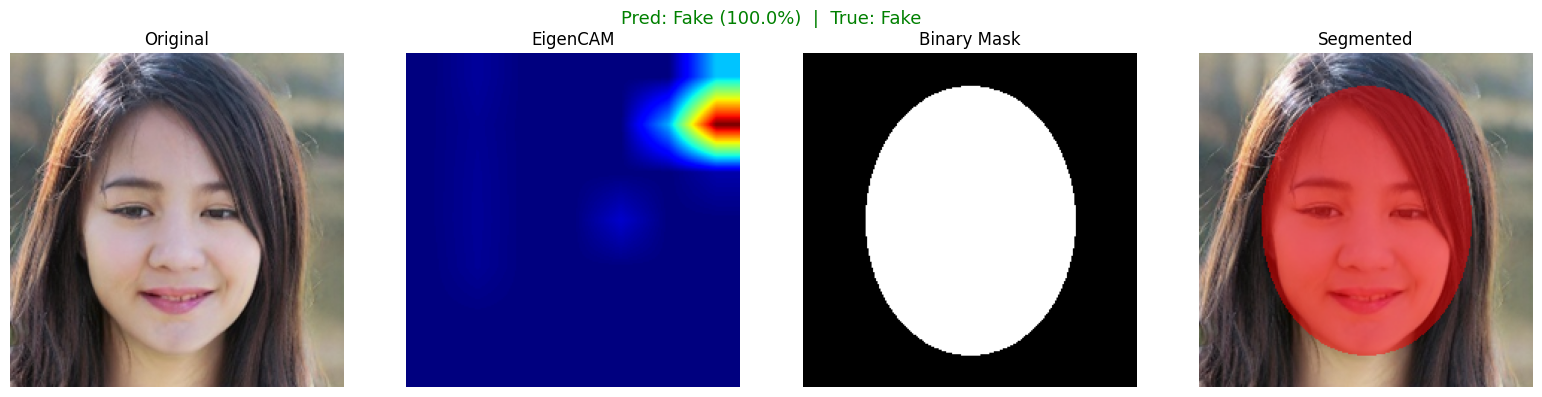

[FAKE] 00276TOPP4.jpg → Fake (100.0%)


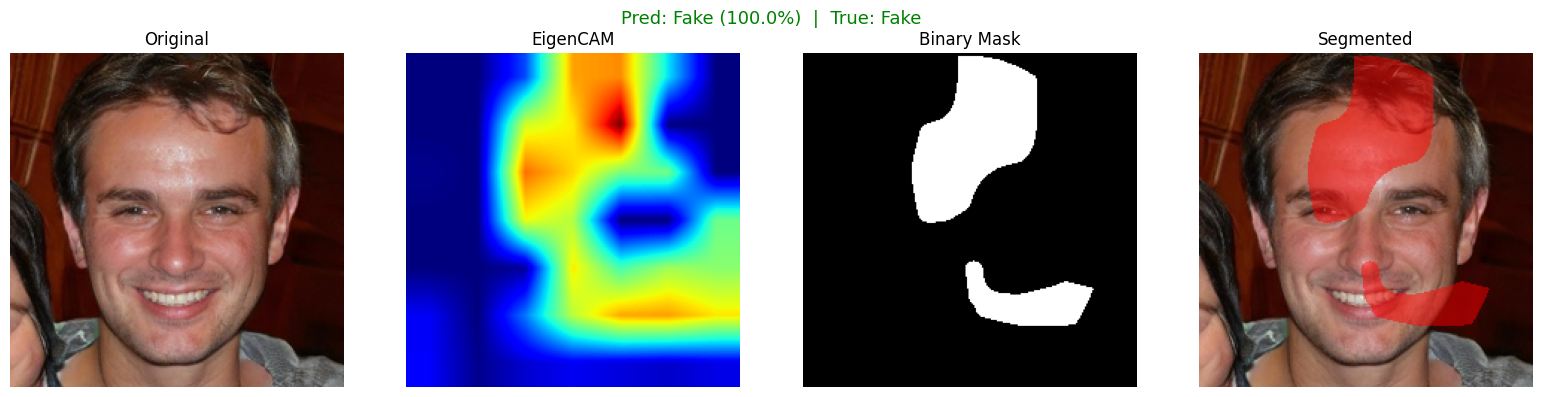

[FAKE] 008BYSE725.jpg → Fake (100.0%)


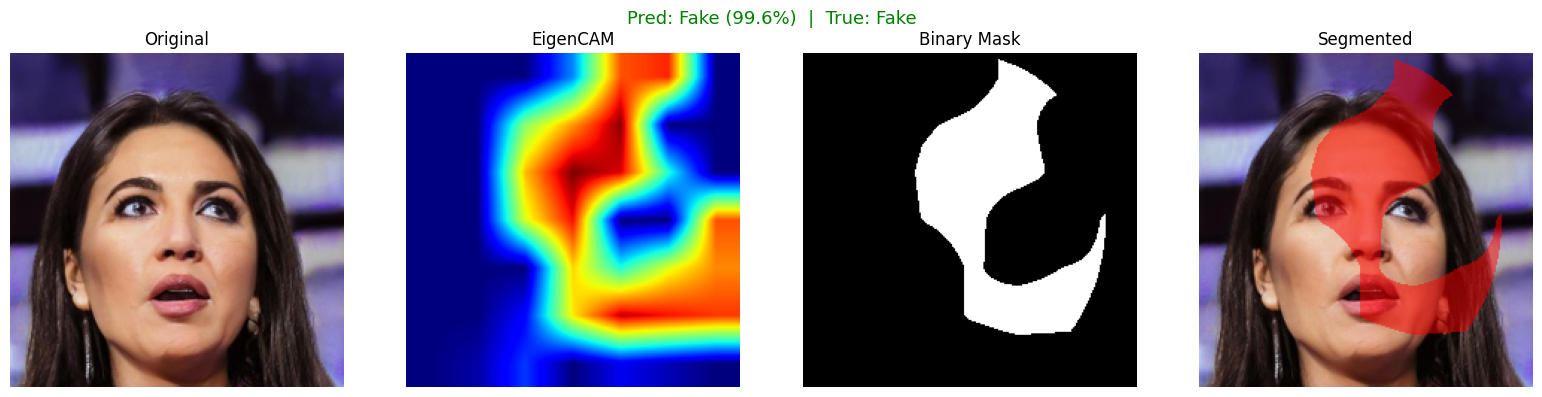

[FAKE] 009ZTJ3621.jpg → Fake (99.6%)


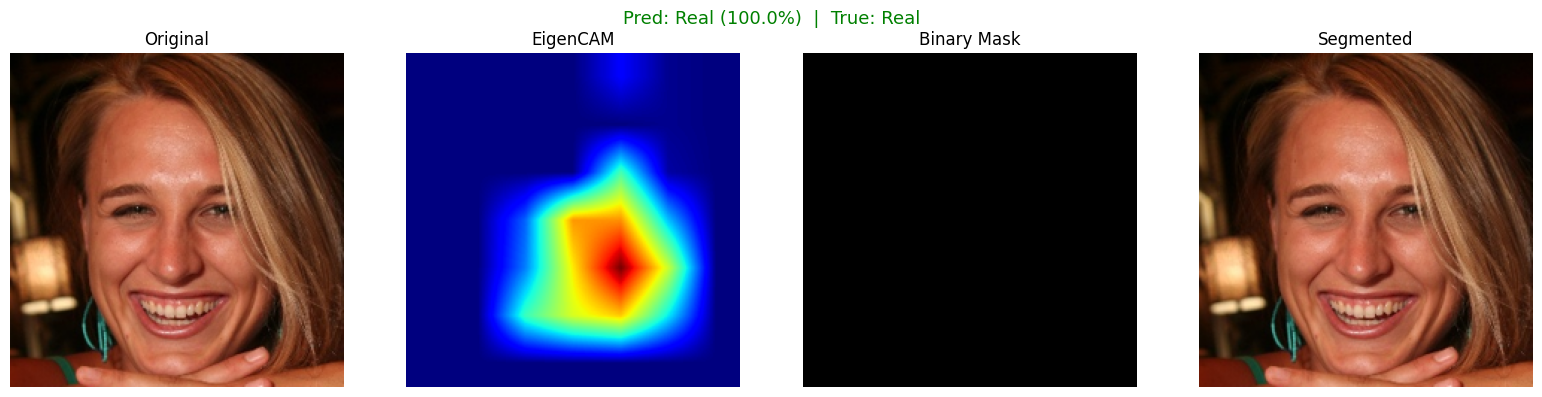

[REAL] 00001.jpg → Real (100.0%)


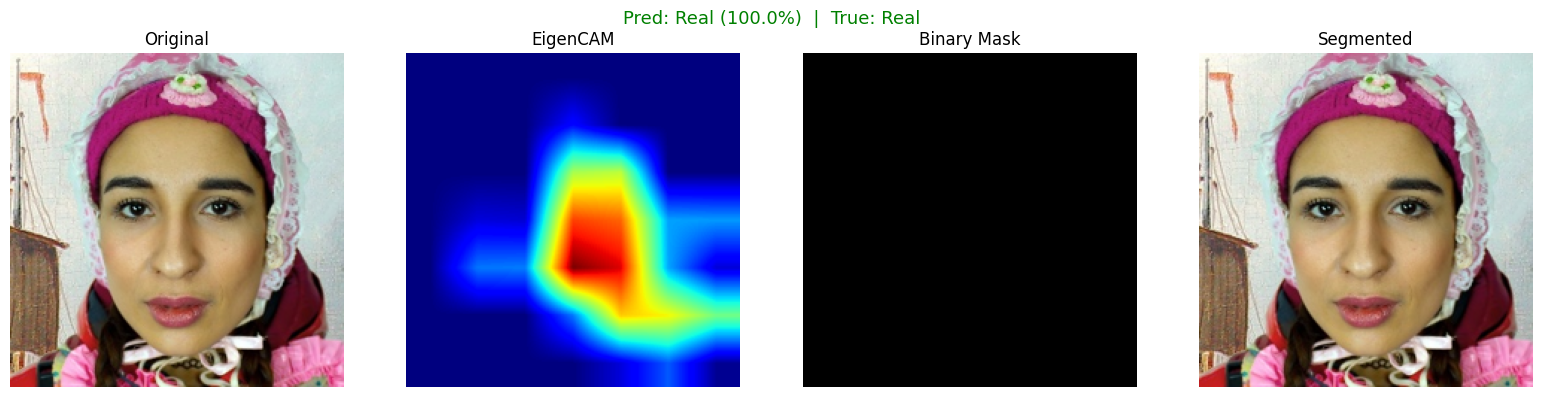

[REAL] 00004.jpg → Real (100.0%)


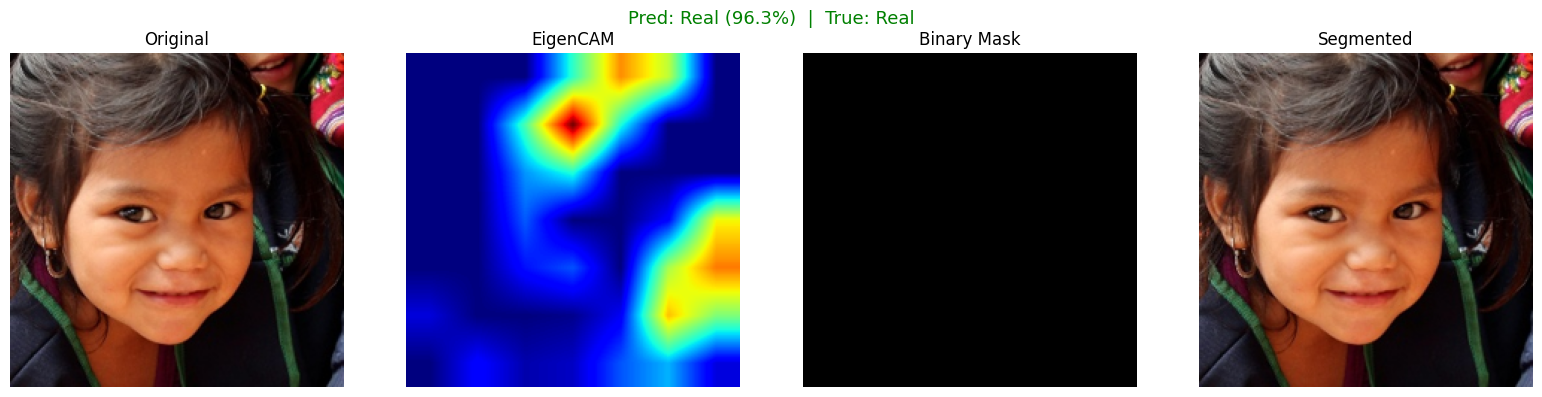

[REAL] 00007.jpg → Real (96.3%)


In [34]:
sample_images = [
    (f'{DATA_ROOT}/test/fake', 'fake'),
    (f'{DATA_ROOT}/test/real', 'real'),
]

for folder, true_label in sample_images:
    imgs = sorted(os.listdir(folder))[:3]
    for img_name in imgs:
        img_path = os.path.join(folder, img_name)
        pred_label, conf, mask = run_segmentation(img_path, true_label=true_label)
        print(f"[{true_label.upper()}] {img_name} → {pred_label} ({conf*100:.1f}%)")

In [39]:
from matplotlib.patches import FancyBboxPatch
from matplotlib.gridspec import GridSpec
import matplotlib.patheffects as pe

VIZ_OUTPUT_DIR = '/kaggle/working/outputs/visualize'
os.makedirs(VIZ_OUTPUT_DIR, exist_ok=True)

print("✅ Visualize imports done!")

✅ Visualize imports done!


In [40]:
def run_visualize(img_path, true_label=None, threshold=0.6):
    # ── Get heatmap & prediction ──────────────────────────────────────────────
    pil_img = Image.open(img_path).convert('RGB').resize((224, 224))
    rgb_img = np.array(pil_img, dtype=np.float32) / 255.0
    input_t = preprocess(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_t)
        probs  = torch.softmax(logits, dim=1)
        pred   = probs.argmax(dim=1).item()
        conf   = probs[0, pred].item()

    with EigenCAM(model=model, target_layers=target_layer) as cam:
        targets   = [ClassifierOutputTarget(pred)]
        grayscale = cam(input_tensor=input_t, targets=targets)[0]

    heatmap = show_cam_on_image(rgb_img, grayscale, use_rgb=True)

    # ── Binary mask ───────────────────────────────────────────────────────────
    if pred == 1:
        binary_mask = (grayscale >= threshold).astype(np.uint8) * 255
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN,  kernel)
        center_mask = np.zeros((224, 224), dtype=np.uint8)
        cv2.ellipse(center_mask, (112, 112), (90, 110), 0, 0, 360, 255, -1)
        binary_mask = cv2.bitwise_and(binary_mask, center_mask)

        # Fallback
        weak_localisation = False
        if cv2.countNonZero(binary_mask) == 0:
            weak_localisation = True
            cv2.ellipse(binary_mask, (112, 112), (70, 90), 0, 0, 360, 255, -1)
    else:
        binary_mask = np.zeros((224, 224), dtype=np.uint8)
        weak_localisation = False

    # ── Red overlay ───────────────────────────────────────────────────────────
    overlay = (rgb_img * 255).astype(np.uint8).copy()
    if pred == 1:
        red_layer = np.zeros_like(overlay)
        red_layer[:, :, 0] = 255
        mask_bool = binary_mask.astype(bool)
        overlay[mask_bool] = (0.5 * overlay[mask_bool] + 0.5 * red_layer[mask_bool]).astype(np.uint8)
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay, contours, -1, (255, 0, 0), 2)

    # ── Localisation score ────────────────────────────────────────────────────
    loc_score = float(grayscale[binary_mask > 0].mean()) if cv2.countNonZero(binary_mask) > 0 else 0.0

    # ── Figure ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 5), facecolor='#0f0f0f')
    gs  = GridSpec(1, 4, figure=fig, wspace=0.05)

    panels = [
        (pil_img,               'Original'),
        (heatmap,               'EigenCAM Heatmap'),
        (binary_mask,           'Binary Mask'),
        (overlay,               'Localisation Output'),
    ]

    cmaps = [None, None, 'gray', None]

    for i, ((img_data, title), cmap) in enumerate(zip(panels, cmaps)):
        ax = fig.add_subplot(gs[i])
        ax.imshow(img_data, cmap=cmap)
        ax.set_title(title, color='white', fontsize=11, pad=8, fontweight='bold')
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_visible(False)

    # ── Header bar ────────────────────────────────────────────────────────────
    pred_color  = '#ff4444' if pred == 1 else '#44ff88'
    pred_text   = f"{'DEEPFAKE DETECTED' if pred == 1 else 'AUTHENTIC'}"
    conf_text   = f"Confidence: {conf*100:.1f}%"
    loc_text    = f"Localisation Score: {loc_score*100:.1f}%"
    if weak_localisation:
        loc_text += "  ⚠ Weak — fallback region used"

    true_text = ""
    if true_label:
        match = true_label.lower() == LABELS[pred].lower()
        true_text = f"  |  GT: {true_label.upper()}  {'✓' if match else '✗'}"

    fig.text(0.5, 1.01,
             f"{pred_text}   {conf_text}   {loc_text}{true_text}",
             ha='center', va='bottom', fontsize=12,
             color=pred_color, fontweight='bold',
             transform=fig.transFigure)

    fig.text(0.5, -0.02,
             os.path.basename(img_path),
             ha='center', fontsize=9, color='#888888',
             transform=fig.transFigure)

    fname = os.path.join(VIZ_OUTPUT_DIR, os.path.basename(img_path))
    plt.savefig(fname, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved → {fname}")

print("✅ Visualize function defined!")

✅ Visualize function defined!


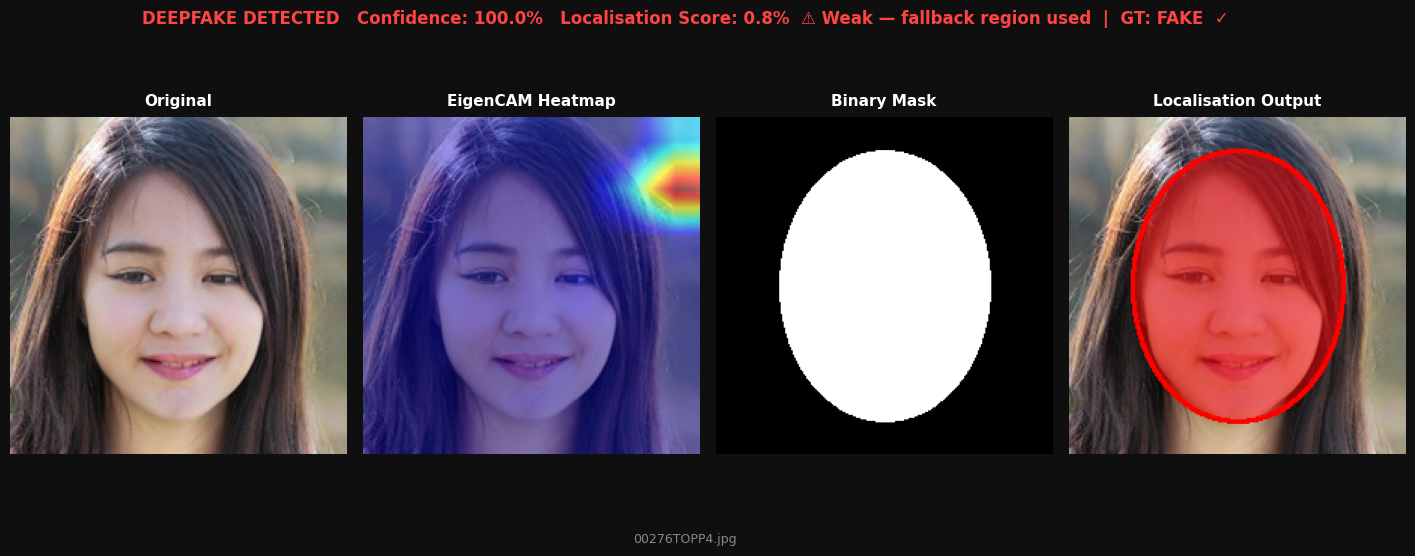

Saved → /kaggle/working/outputs/visualize/00276TOPP4.jpg


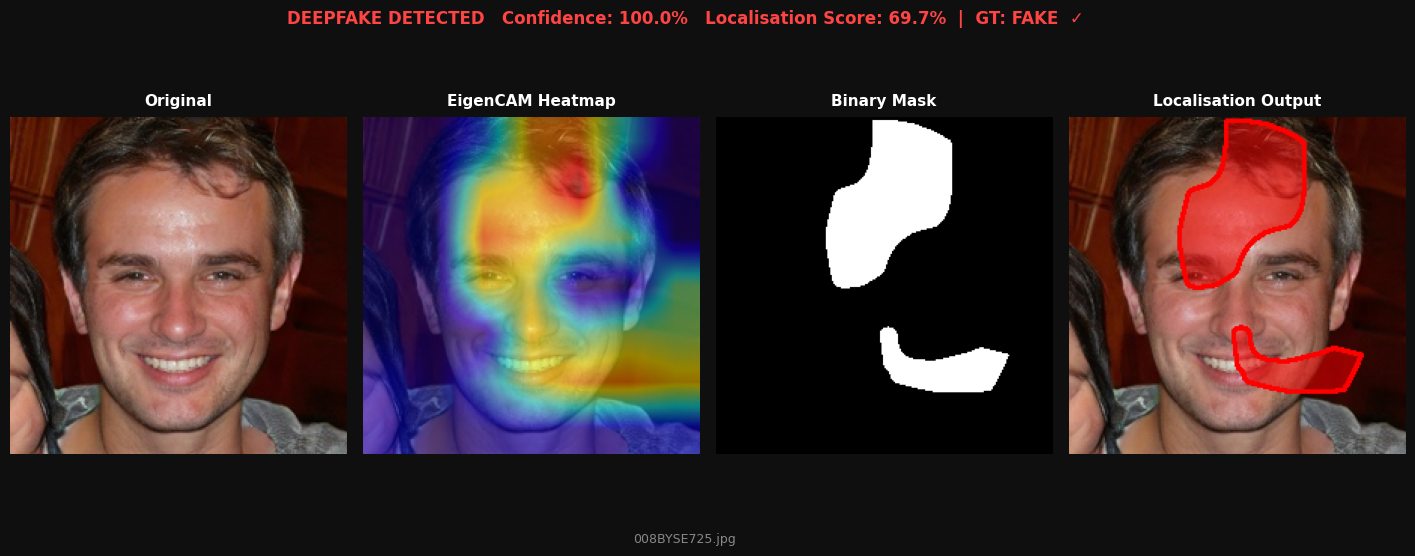

Saved → /kaggle/working/outputs/visualize/008BYSE725.jpg


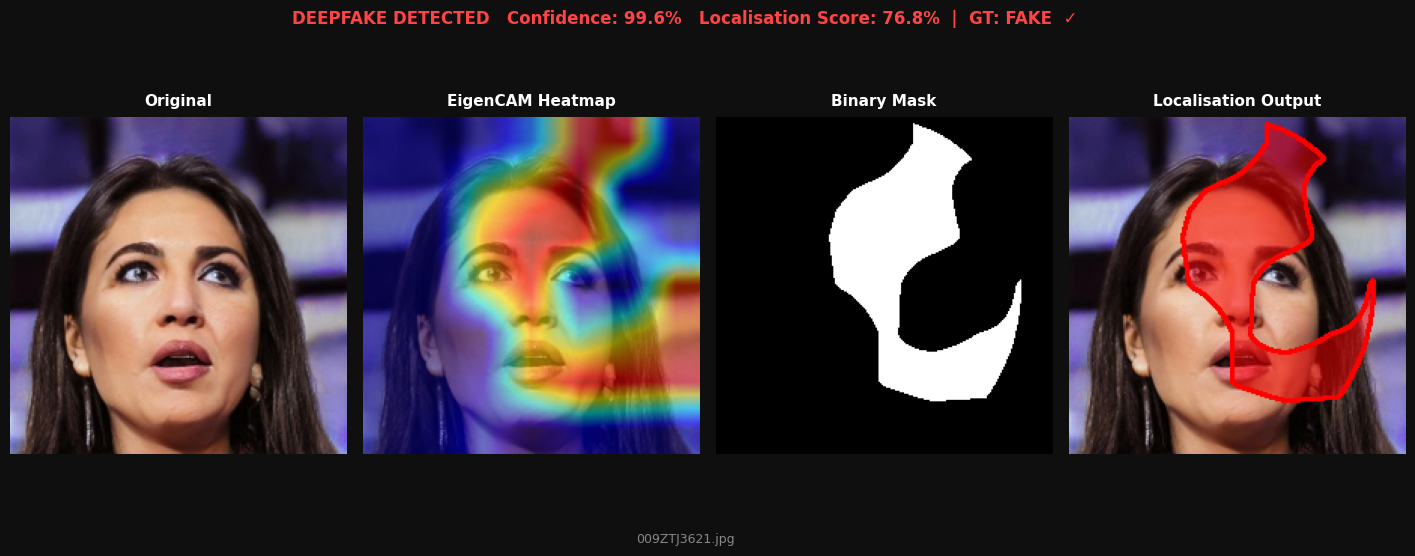

Saved → /kaggle/working/outputs/visualize/009ZTJ3621.jpg


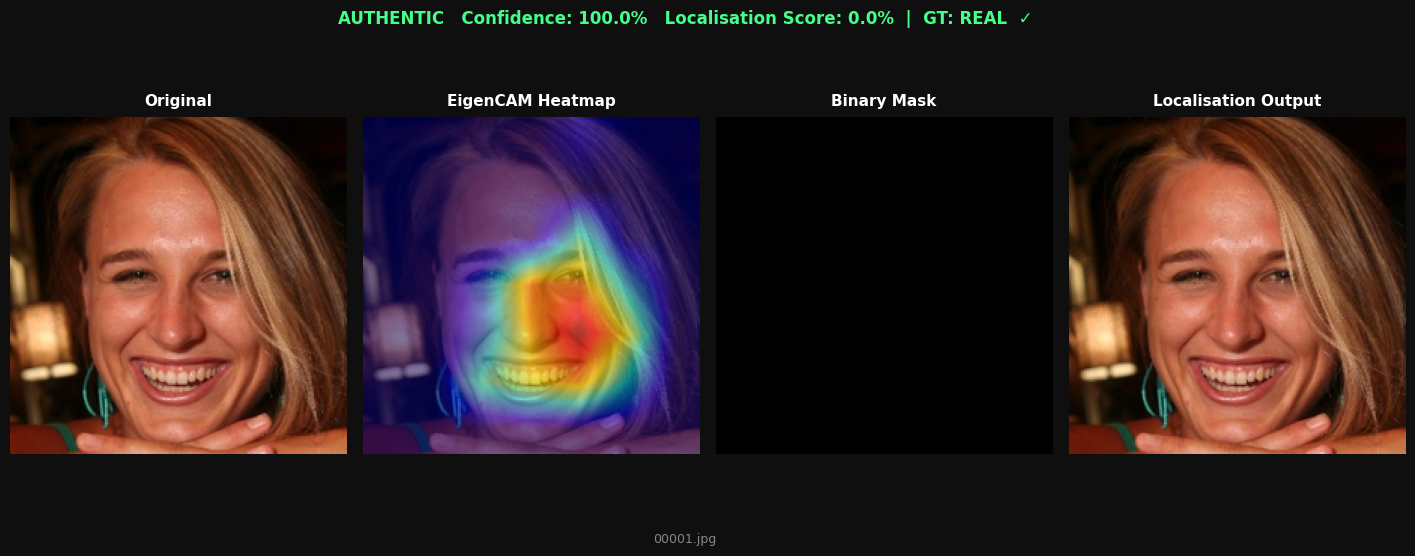

Saved → /kaggle/working/outputs/visualize/00001.jpg


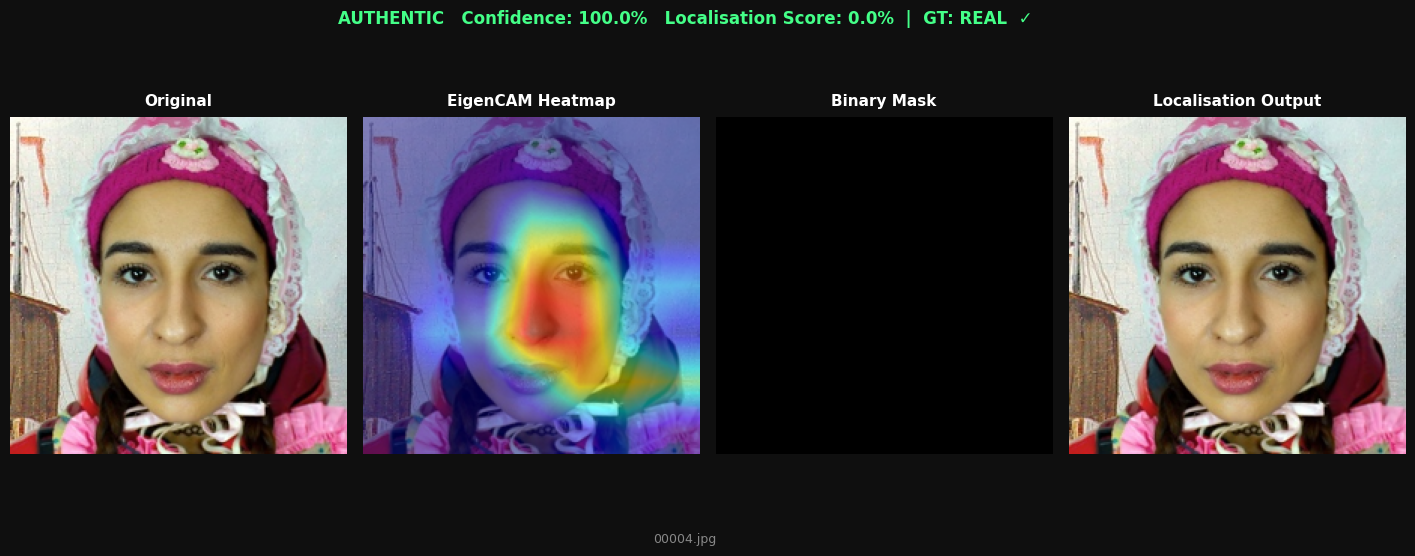

Saved → /kaggle/working/outputs/visualize/00004.jpg


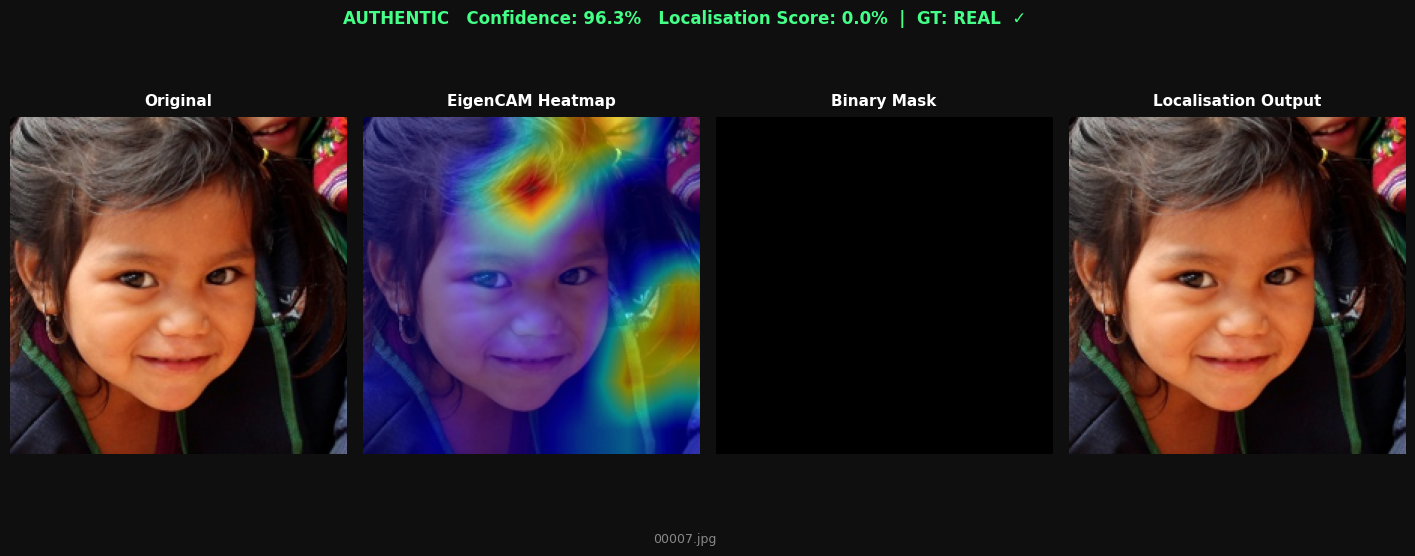

Saved → /kaggle/working/outputs/visualize/00007.jpg


In [37]:
sample_images = [
    (f'{DATA_ROOT}/test/fake', 'fake'),
    (f'{DATA_ROOT}/test/real', 'real'),
]

for folder, true_label in sample_images:
    imgs = sorted(os.listdir(folder))[:3]
    for img_name in imgs:
        img_path = os.path.join(folder, img_name)
        run_visualize(img_path, true_label=true_label)

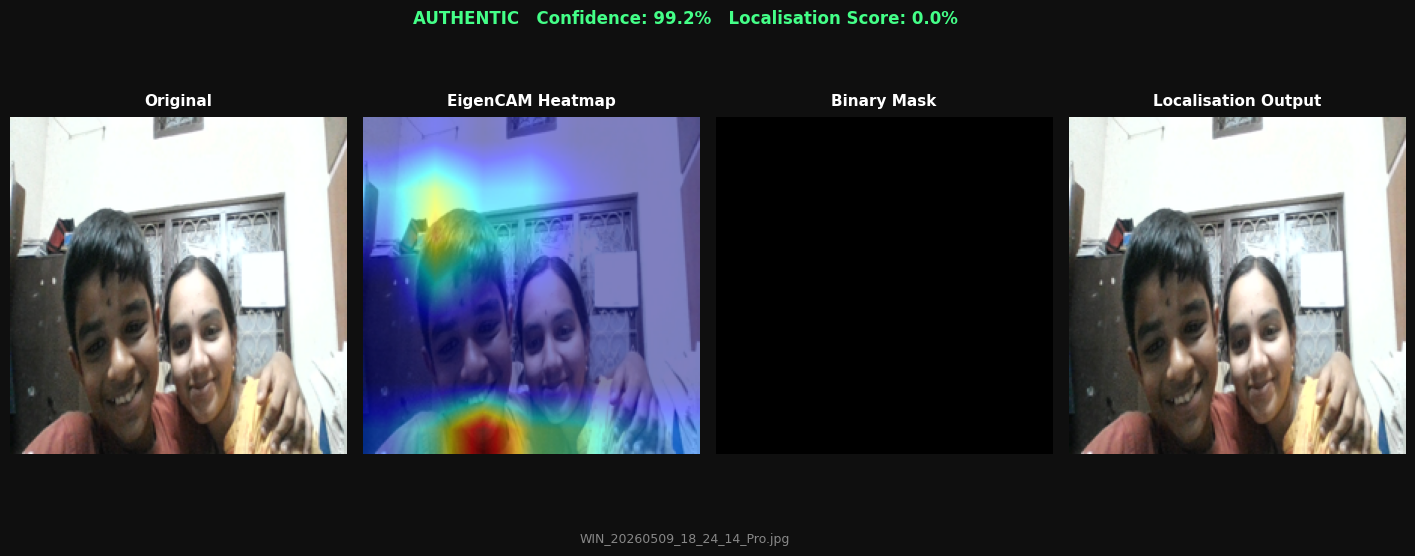

Saved → /kaggle/working/outputs/visualize/WIN_20260509_18_24_14_Pro.jpg


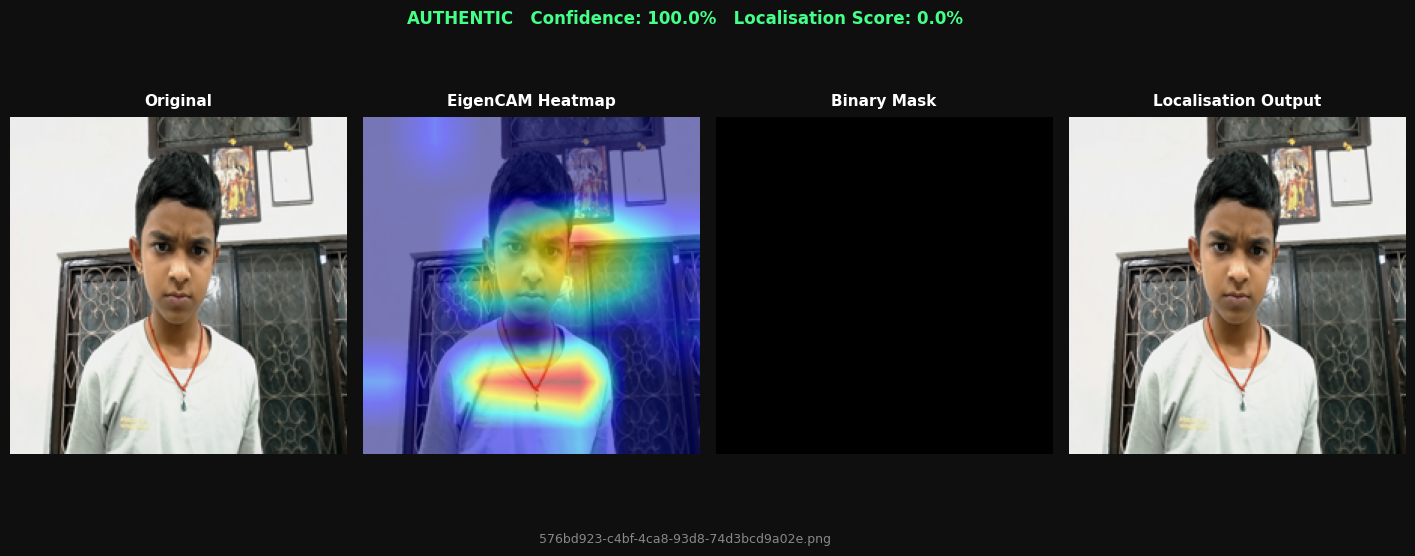

Saved → /kaggle/working/outputs/visualize/576bd923-c4bf-4ca8-93d8-74d3bcd9a02e.png


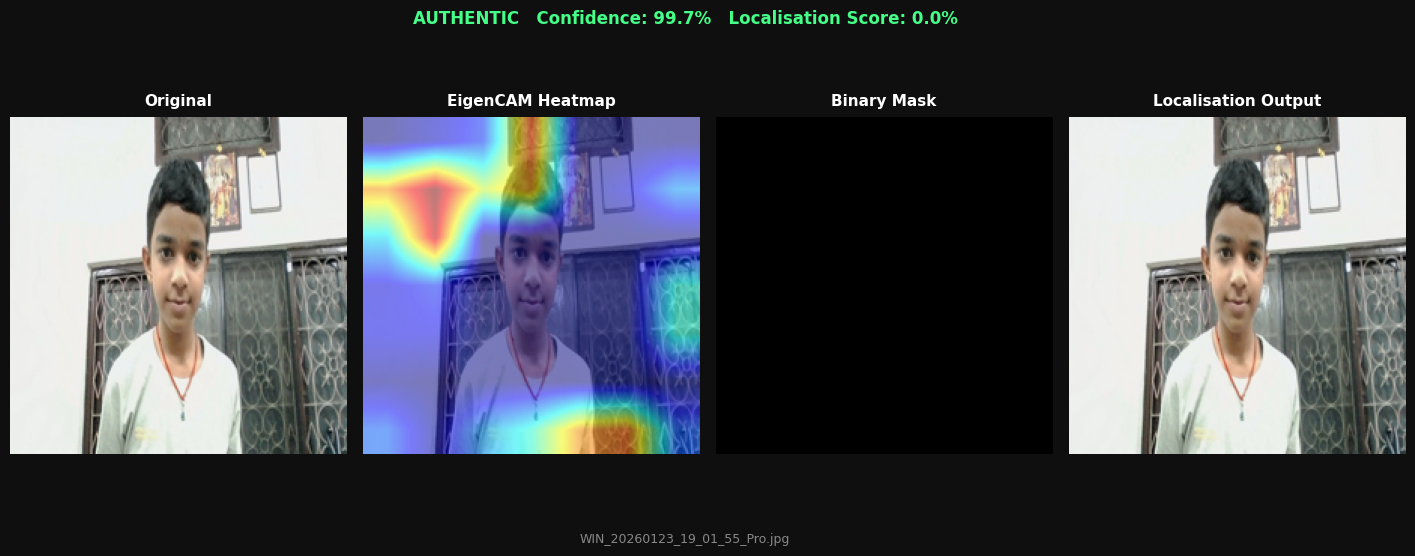

Saved → /kaggle/working/outputs/visualize/WIN_20260123_19_01_55_Pro.jpg


In [41]:
import os

MY_IMAGES_DIR = '/kaggle/input/datasets/dhathrikarthik/testdataset'

for img_name in os.listdir(MY_IMAGES_DIR):
    if img_name.endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(MY_IMAGES_DIR, img_name)
        run_visualize(img_path)  # no true_label since you may not know

In [9]:
import os
for item in os.listdir('/kaggle/input/datasets/dhathrikarthik'):
    print(item)

testdataset
deepfake-classifier-weights


In [3]:
import torch
checkpoint = torch.load('/kaggle/input/datasets/dhathrikarthik/deepfake-classifier-weights/deepfake_classifier.pth', map_location='cpu')
print(type(checkpoint))          # dict? OrderedDict?
print(list(checkpoint.keys())[:5])  # what are the key names?

<class 'collections.OrderedDict'>
['model.features.0.0.weight', 'model.features.0.1.weight', 'model.features.0.1.bias', 'model.features.0.1.running_mean', 'model.features.0.1.running_var']


In [4]:
from torchvision.datasets import ImageFolder
ds = ImageFolder('/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/train')
print(ds.class_to_idx)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/train'

In [5]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/train.csv')
print(df.head(10))
print(df['label'].value_counts())
print(df['label'].unique())

   Unnamed: 0                                      original_path     id  \
0           0  /kaggle/input/flickrfaceshq-dataset-nvidia-par...  31355   
1           1  /kaggle/input/flickrfaceshq-dataset-nvidia-par...  02884   
2           2  /kaggle/input/flickrfaceshq-dataset-nvidia-par...  33988   
3           3  /kaggle/input/flickrfaceshq-dataset-nvidia-par...  53875   
4           4  /kaggle/input/flickrfaceshq-dataset-nvidia-par...  24149   
5           5  /kaggle/input/flickrfaceshq-dataset-nvidia-par...  30627   
6           6  /kaggle/input/flickrfaceshq-dataset-nvidia-par...  62493   
7           7  /kaggle/input/flickrfaceshq-dataset-nvidia-par...  41925   
8           8  /kaggle/input/flickrfaceshq-dataset-nvidia-par...  62701   
9           9  /kaggle/input/flickrfaceshq-dataset-nvidia-par...  52219   

   label label_str                  path  
0      1      real  train/real/31355.jpg  
1      1      real  train/real/02884.jpg  
2      1      real  train/real/33988.jpg  
3 